# TP1 — Baseline Clássico
## RSNA 2023 · Screening Mammography Breast Cancer Detection

**Disciplina:** Tópicos Especiais em Sistemas de Informação
**Grupo:** G6 — Marcos Felipe Arruda Lima, Adrian Lucas Pinheiro Silva, Igor Holanda Costa
**Desafio:** RSNA Screening Mammography Breast Cancer Detection (2023)

Este notebook cobre a Semana 1 e 2 do cronograma (fundação, EDA, pipeline de
pré-processamento e baseline trivial) e serve de esqueleto para as Semanas 3-4
(extração de descritores e experimentos comparativos).

> **Nota:** os caminhos de dados abaixo são placeholders. Ajuste
> `DATA_DIR` assim que baixar a amostra do Kaggle. A estrutura esperada do
> dataset original é:
> ```
> DATA_DIR/
>   train.csv
>   train_images/
>     <patient_id>/
>       <image_id>.dcm
> ```
> Colunas esperadas em `train.csv`: `site_id, patient_id, image_id, laterality,
> view, age, cancer, biopsy, invasive, BIRADS, implant, density, machine_id,
> difficult_negative_case`.


In [1]:
!pip install -q pylibjpeg pylibjpeg-libjpeg pylibjpeg-openjpeg python-gdcm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 28.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 74.8 MB/s eta 0:00:00:00:0100:01


In [2]:
# ==== Imports ====
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import pydicom
from pydicom.pixel_data_handlers.util import apply_voi_lut

import cv2
from skimage import exposure

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, balanced_accuracy_score

sns.set_theme(style="whitegrid")


In [4]:
# ==== Configuração / reprodutibilidade ====
SEED = 42
np.random.seed(SEED)

DATA_DIR = "/kaggle/input/competitions/rsna-breast-cancer-detection" # TODO: ajustar após baixar a amostra
OUTPUT_DIR = "/kaggle/working" 

TRAIN_CSV = os.path.join(DATA_DIR, "train.csv")
IMAGES_DIR = os.path.join(DATA_DIR, "train_images")

N_FOLDS = 5
TARGET_COL = "cancer"
GROUP_COL = "patient_id"


## 1. Carregamento dos dados

In [5]:
if os.path.exists(TRAIN_CSV):
    df = pd.read_csv(TRAIN_CSV)
    print(f"Registros carregados: {len(df)}")
    display(df.head())
else:
    print(
        "train.csv não encontrado em", TRAIN_CSV,
        "\n-> Baixe a amostra estratificada do Kaggle e ajuste DATA_DIR antes de continuar."
    )
    df = pd.DataFrame()  # placeholder para o notebook não quebrar


Registros carregados: 54706


,site_id,patient_id,image_id,laterality,view,age,cancer,biopsy,invasive,BIRADS,implant,density,machine_id,difficult_negative_case
0,2,10006,462822612,L,CC,61.0,0,0,0,NaN,0,NaN,29,False
1,2,10006,1459541791,L,MLO,61.0,0,0,0,NaN,0,NaN,29,False
2,2,10006,1864590858,R,MLO,61.0,0,0,0,NaN,0,NaN,29,False
3,2,10006,1874946579,R,CC,61.0,0,0,0,NaN,0,NaN,29,False
4,2,10011,220375232,L,CC,55.0,0,0,0,0.0,0,NaN,21,True


## 2. Análise exploratória (EDA)

Objetivo: confirmar o desbalanceamento extremo (~2% de positivos citado no
enunciado), entender a distribuição por vista/lateralidade/densidade e contar
exames e pacientes distintos — tudo isso entra no relatório do AP1.

Pacientes distintos: 11913
Imagens/exames distintos: 54706
Taxa de positivos (cancer=1): 2.1168%


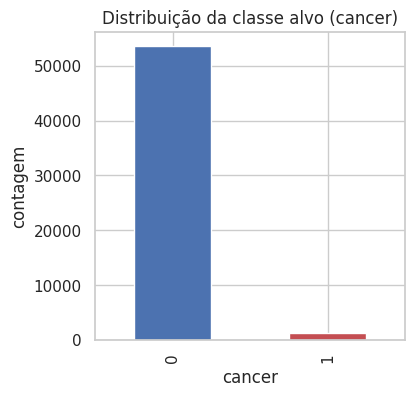

In [6]:
if not df.empty:
    n_patients = df[GROUP_COL].nunique()
    n_exams = df["image_id"].nunique()
    pos_rate = df[TARGET_COL].mean()

    print(f"Pacientes distintos: {n_patients}")
    print(f"Imagens/exames distintos: {n_exams}")
    print(f"Taxa de positivos (cancer=1): {pos_rate:.4%}")

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    df[TARGET_COL].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
    ax.set_title("Distribuição da classe alvo (cancer)")
    ax.set_xlabel("cancer")
    ax.set_ylabel("contagem")
    plt.show()


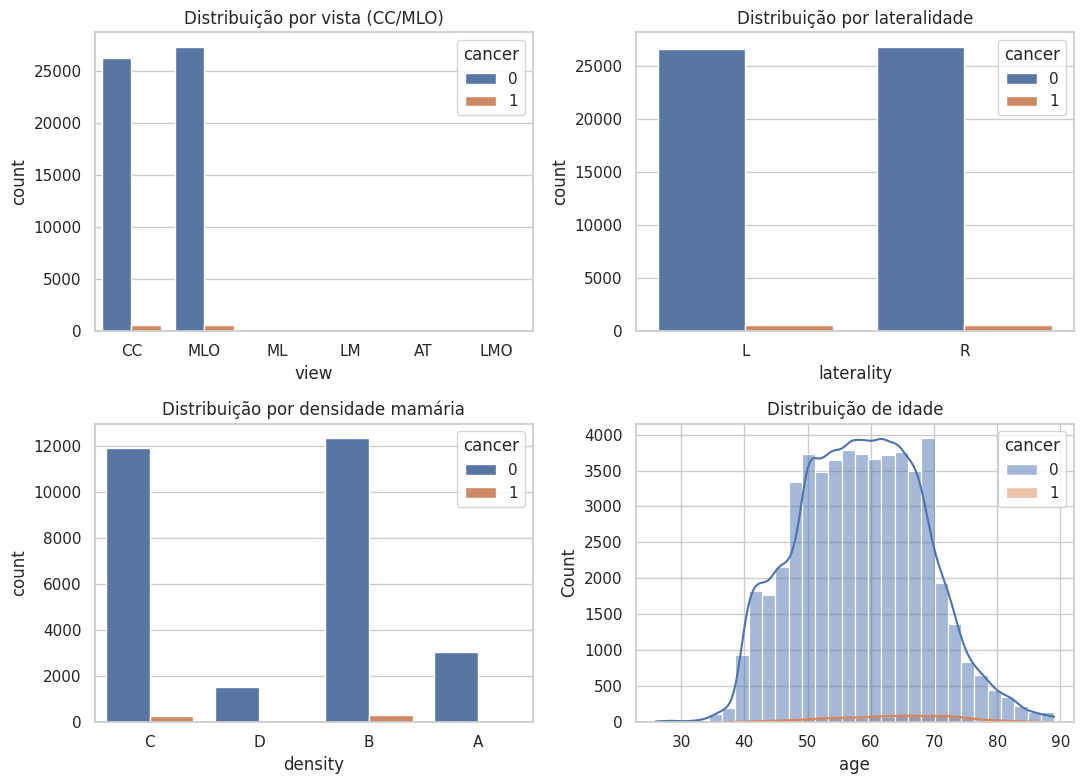

In [7]:
if not df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(11, 8))

    sns.countplot(data=df, x="view", hue=TARGET_COL, ax=axes[0, 0])
    axes[0, 0].set_title("Distribuição por vista (CC/MLO)")

    sns.countplot(data=df, x="laterality", hue=TARGET_COL, ax=axes[0, 1])
    axes[0, 1].set_title("Distribuição por lateralidade")

    if "density" in df.columns:
        sns.countplot(data=df, x="density", hue=TARGET_COL, ax=axes[1, 0])
        axes[1, 0].set_title("Distribuição por densidade mamária")

    if "age" in df.columns:
        sns.histplot(data=df, x="age", hue=TARGET_COL, kde=True, ax=axes[1, 1], bins=30)
        axes[1, 1].set_title("Distribuição de idade")

    plt.tight_layout()
    plt.show()


## 3. Leitura de DICOM e metadados

A densidade mamária, a lateralidade e a vista já vêm no `train.csv`, mas os
metadados de aquisição (VOI LUT, PhotometricInterpretation, PixelSpacing) só
existem no próprio DICOM e afetam diretamente o pré-processamento.

In [9]:
def read_dicom_metadata(path):
    """Lê um DICOM e retorna um dicionário com os metadados relevantes."""
    dcm = pydicom.dcmread(path)
    meta = {
        "Modality": getattr(dcm, "Modality", None),
        "PhotometricInterpretation": getattr(dcm, "PhotometricInterpretation", None),
        "PixelSpacing": getattr(dcm, "PixelSpacing", None),
        "Rows": getattr(dcm, "Rows", None),
        "Columns": getattr(dcm, "Columns", None),
        "WindowCenter": getattr(dcm, "WindowCenter", None),
        "WindowWidth": getattr(dcm, "WindowWidth", None),
        "BitsStored": getattr(dcm, "BitsStored", None),
    }
    return dcm, meta


def load_dicom_image(path, apply_voi=True):
    """Lê um DICOM e devolve a imagem 2D já normalizada para [0, 255] (uint8)."""
    dcm = pydicom.dcmread(path)
    img = dcm.pixel_array.astype(np.float32)

    if apply_voi:
        img = apply_voi_lut(img, dcm)

    # Mamografias MONOCHROME1 têm a escala de cinza invertida
    if getattr(dcm, "PhotometricInterpretation", "") == "MONOCHROME1":
        img = img.max() - img

    img = img - img.min()
    if img.max() > 0:
        img = img / img.max()
    return (img * 255).astype(np.uint8)


# Exemplo de uso (ajuste o caminho para um arquivo real depois de baixar os dados):
# sample_path = os.path.join(IMAGES_DIR, "<patient_id>", "<image_id>.dcm")
# dcm, meta = read_dicom_metadata(sample_path)
# print(meta)


## 4. Visualização de exemplos por classe

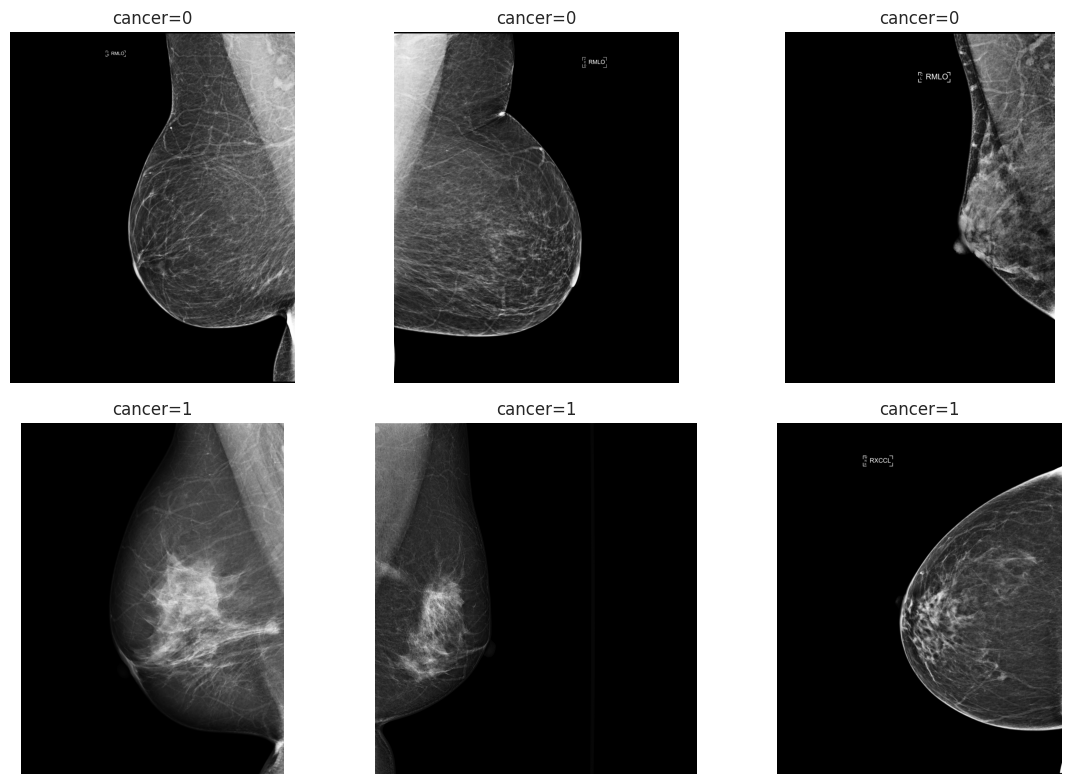

In [10]:
def show_examples(df, images_dir, n_per_class=3):
    """Mostra n_per_class exemplos de cada classe (cancer=0 e cancer=1)."""
    fig, axes = plt.subplots(2, n_per_class, figsize=(4 * n_per_class, 8))

    for row_idx, label in enumerate([0, 1]):
        subset = df[df[TARGET_COL] == label].sample(
            min(n_per_class, (df[TARGET_COL] == label).sum()), random_state=SEED
        )
        for col_idx, (_, row) in enumerate(subset.iterrows()):
            path = os.path.join(images_dir, str(row[GROUP_COL]), f"{row['image_id']}.dcm")
            try:
                img = load_dicom_image(path)
                axes[row_idx, col_idx].imshow(img, cmap="gray")
            except FileNotFoundError:
                axes[row_idx, col_idx].text(0.5, 0.5, "arquivo não encontrado", ha="center")
            axes[row_idx, col_idx].set_title(f"cancer={label}")
            axes[row_idx, col_idx].axis("off")

    plt.tight_layout()
    plt.show()


if not df.empty:
    show_examples(df, IMAGES_DIR)


## 5. Pipeline de pré-processamento

Etapas pensadas especificamente para mamografia de triagem:

1. **VOI LUT / janelamento** — já aplicado em `load_dicom_image`.
2. **Remoção de fundo e marcadores** — thresholding + maior componente conexo
   para manter só o tecido mamário.
3. **Recorte da ROI (mama)** — bounding box do maior contorno.
4. **Realce de contraste (CLAHE)** — ajuda a destacar microcalcificações sem
   estourar a dinâmica da imagem inteira.
5. **Redimensionamento cuidadoso** — evitar reduzir demais a resolução, para
   não perder achados de poucos pixels (erro comum apontado no enunciado).

In [11]:
def remove_background(img):
    """Segmenta a mama removendo fundo escuro e marcadores, via Otsu + maior
    componente conexo."""
    _, mask = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Limpa ruído fino (linhas de artefato, marcadores pequenos) ANTES de
    # procurar o maior componente conexo
    kernel = np.ones((15, 15), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    if n_labels <= 1:
        return img, mask

    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    breast_mask = (labels == largest_label).astype(np.uint8) * 255

    result = cv2.bitwise_and(img, img, mask=breast_mask)
    return result, breast_mask

def crop_to_roi(img, mask, margin=10):
    """Recorta a imagem para o bounding box do tecido mamário (mask)."""
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return img
    x0, x1 = max(xs.min() - margin, 0), min(xs.max() + margin, img.shape[1])
    y0, y1 = max(ys.min() - margin, 0), min(ys.max() + margin, img.shape[0])
    return img[y0:y1, x0:x1]


def enhance_contrast(img, clip_limit=1.0, tile_grid_size=(8, 8)):  
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(img)


def preprocess_image(path, target_size=(1024, 1024)):
    """Pipeline completo: carrega DICOM -> remove fundo -> recorta ROI ->
    realça contraste -> redimensiona."""
    img = load_dicom_image(path)
    img, mask = remove_background(img)
    img = crop_to_roi(img, mask)
    img = enhance_contrast(img)
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    return img


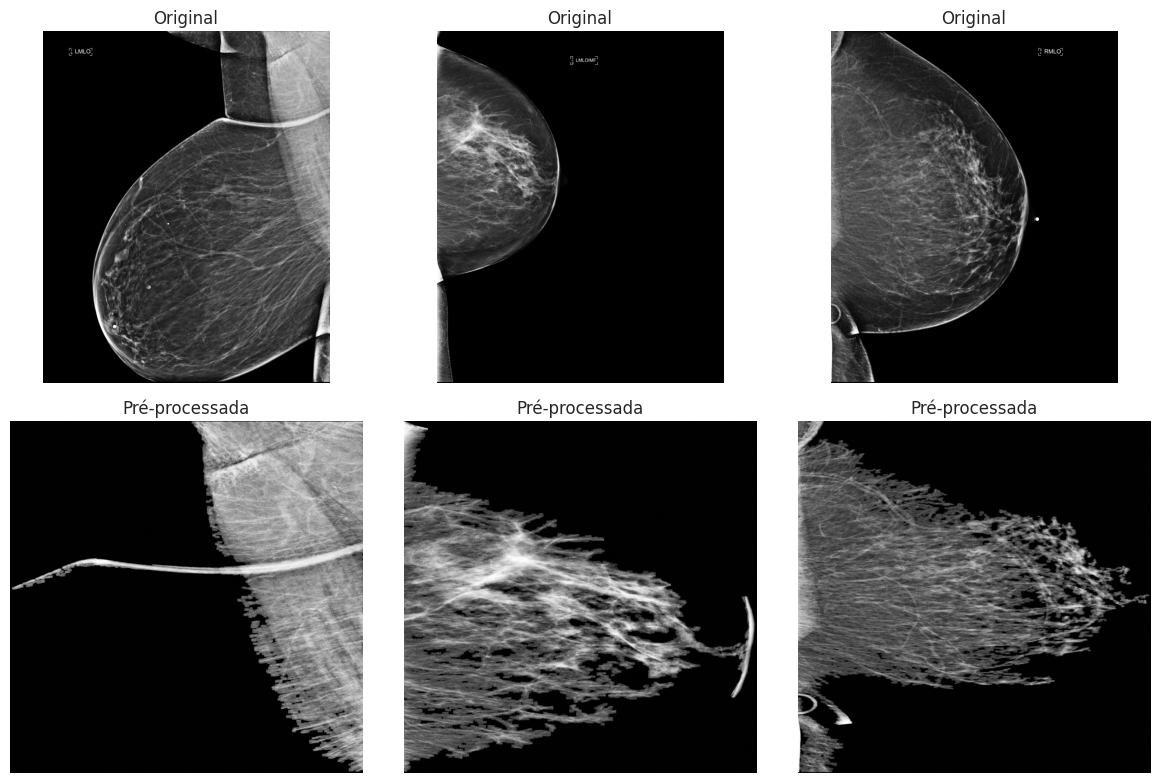

In [12]:
# Demonstração antes/depois em algumas imagens de exemplo
def show_before_after(df, images_dir, n_examples=3):
    sample = df.sample(min(n_examples, len(df)), random_state=SEED)
    fig, axes = plt.subplots(2, n_examples, figsize=(4 * n_examples, 8))

    for i, (_, row) in enumerate(sample.iterrows()):
        path = os.path.join(images_dir, str(row[GROUP_COL]), f"{row['image_id']}.dcm")
        try:
            raw = load_dicom_image(path)
            processed = preprocess_image(path)
            axes[0, i].imshow(raw, cmap="gray")
            axes[0, i].set_title("Original")
            axes[1, i].imshow(processed, cmap="gray")
            axes[1, i].set_title("Pré-processada")
        except FileNotFoundError:
            axes[0, i].text(0.5, 0.5, "arquivo não encontrado", ha="center")
        axes[0, i].axis("off")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()


if not df.empty:
    show_before_after(df, IMAGES_DIR)


## 6. Particionamento por paciente (StratifiedGroupKFold)

**Importante:** o particionamento é feito por `patient_id`, nunca por imagem
— cortes/exames do mesmo paciente não podem aparecer em treino e teste ao
mesmo tempo (vazamento de dados, erro nº 1 apontado no enunciado).

In [13]:
if not df.empty:
    sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

    df["fold"] = -1
    for fold_idx, (_, val_idx) in enumerate(
        sgkf.split(df, y=df[TARGET_COL], groups=df[GROUP_COL])
    ):
        df.loc[val_idx, "fold"] = fold_idx

    print(df.groupby("fold")[TARGET_COL].agg(["count", "mean"]))

    # Congelar a partição para uso em todas as etapas seguintes do trabalho
    df.to_csv(os.path.join(OUTPUT_DIR, "train_with_folds.csv"), index=False)


      count      mean
fold                 
0     10979  0.021222
1     10879  0.021601
2     11012  0.022612
3     10891  0.020292
4     10945  0.020101


## 7. Baseline trivial

Classificador de classe majoritária — referência obrigatória para interpretar
qualquer métrica nas próximas etapas, já que a acurácia isolada não tem
significado com ~2% de positivos.

In [14]:
if not df.empty:
    aucs, aps, bals = [], [], []

    for fold in sorted(df["fold"].unique()):
        train_fold = df[df["fold"] != fold]
        val_fold = df[df["fold"] == fold]

        clf = DummyClassifier(strategy="most_frequent", random_state=SEED)
        clf.fit(train_fold[[GROUP_COL]], train_fold[TARGET_COL])

        # DummyClassifier não gera score real; usamos a taxa de positivos do treino
        # como proxy de score constante para poder calcular AUC/AP nesta baseline.
        y_score = np.full(len(val_fold), train_fold[TARGET_COL].mean())
        y_true = val_fold[TARGET_COL].values

        try:
            auc = roc_auc_score(y_true, y_score)
            ap = average_precision_score(y_true, y_score)
        except ValueError:
            auc, ap = np.nan, np.nan

        y_pred = clf.predict(val_fold[[GROUP_COL]])
        bal_acc = balanced_accuracy_score(y_true, y_pred)

        aucs.append(auc)
        aps.append(ap)
        bals.append(bal_acc)

    print(f"AUC-ROC:  {np.nanmean(aucs):.4f} ± {np.nanstd(aucs):.4f}")
    print(f"AUC-PR:   {np.nanmean(aps):.4f} ± {np.nanstd(aps):.4f}")
    print(f"Bal. Acc: {np.nanmean(bals):.4f} ± {np.nanstd(bals):.4f}")


AUC-ROC:  0.5000 ± 0.0000
AUC-PR:   0.0212 ± 0.0009
Bal. Acc: 0.5000 ± 0.0000


## Próximos passos (Observações) 

- Extrair as demais famílias de descritores (mínimo 3 no total): sugestão —
  textura (GLCM/LBP), radiômica (PyRadiomics) e gradiente/bordas (HOG), dado
  que o sinal principal aqui está em microcalcificações pequenas.
- Treinar e comparar ao menos 3 modelos clássicos (SVM, Random Forest,
  XGBoost/LightGBM, kNN, regressão logística) dentro do mesmo esquema de
  `fold` definido acima.
- Tratar o desbalanceamento extremo (pesos de classe, SMOTE) e discutir os
  efeitos colaterais de cada abordagem.
- Estudo de ablação e análise de erro qualitativa (falsos negativos são
  especialmente importantes de investigar neste desafio).

---
**Nota sobre uso de IA generativa:** Utilizei da "Claude" como uma orientadora no codigo me auxiliando Com possivel duvidas sobre o mal funcionamento do codigo (Ex: no passo 4: Visualização de exemplos por classe em sua primeira etapa o mesmo apresentava uma saturação extrema causando assim a perda de certos tons cinzas função "def enhance_contrast" e tbm em problemas na hora de compilar o DATA_DIR erro na minha escrita do codigo) a mesma tbm revisou o codigo junto de seus resultados em todos os meus testes assim garantindo minha compreensão.